# P1 · PPI Network Analysis
**Input:** `data/processed/dea_results.csv`  
**Outputs:** `results/tables/hub_genes.csv` · `results/tables/ppi_edges_cytoscape.csv`
· `results/figures/ppi_network.png`

**Run order:** 01 → 02 → 03 → 04 → **P1** → P2 → P3 → P4


In [1]:
import sys
from pathlib import Path

def _find_repo_root(start):
    for p in [start, *start.parents]:
        if (p / "paths.py").exists():
            return p
    raise FileNotFoundError("paths.py not found — run: python scripts/data_download.py")

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from paths import REPO_ROOT, PROC_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR
sys.path.insert(0, str(REPO_ROOT / "scripts"))
print(f"Repo root : {REPO_ROOT}")

Repo root : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD


In [2]:
from utils import plot_ppi_network, load_dea, query_string, build_and_score, export_ppi
import matplotlib.pyplot as plt
print("Imports OK")

Imports OK


In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
STRING_SCORE  = 400   # 400=medium, 700=high confidence
LOG2FC_THRESH = 1.0
PADJ_THRESH   = 0.05
TOP_VIZ_NODES = 80    # nodes shown in the network figure

## 1 · Load DEA results

In [4]:
sig, gene_list = load_dea(PROC_DIR / "dea_results.csv",
                          log2fc_thresh=LOG2FC_THRESH,
                          padj_thresh=PADJ_THRESH)
sig.head()

DEGs loaded    : 1385
  Upregulated  : 335
  Downregulated: 1050
  Unique genes : 1385


,gene,log2FC,adj_pvalue,regulation
0,RPS26,1.991955,7.295115e-149,up
1,XIST,31.180847,2.625168e-118,up
2,MALAT1,1.089554,3.200503e-93,up
3,CREM,2.918553,7.829163e-81,up
4,JUND,1.322786,5.349000e-73,up


## 2 · Query STRING API

In [5]:
edges_df = query_string(gene_list,
                        string_score=STRING_SCORE,
                        batch_size=500)
edges_df.head()

  Batch 1: 500 genes... → 2186 interactions
  Batch 2: 500 genes... → 1574 interactions
  Batch 3: 385 genes... → 3999 interactions

Unique interactions: 7759


,gene_A,gene_B,combined_score
0,TSR3,LYAR,0.424
1,TSR3,EBPL,0.483
2,ACAP1,CD6,0.404
3,ACAP1,ARHGAP9,0.477
4,ACAP1,RASA1,0.602


## 3 · Build graph & compute hub scores

In [6]:
G, hub_df = build_and_score(sig, edges_df)
hub_df[["gene","degree","hub_score","regulation"]].head(10)

Nodes : 1162
Edges : 7551


,gene,degree,hub_score,regulation
0,GAPDH,135,0.926926,down
1,CD4,110,0.763489,down
2,IL1B,113,0.750842,down
3,ALB,97,0.691624,down
4,APOE,94,0.649482,down
5,MMP9,84,0.601919,down
6,CTSS,85,0.587974,down
7,CSF1R,77,0.574566,down
8,CXCL8,74,0.568251,down
9,CD68,77,0.567907,down


## 4 · Visualise network

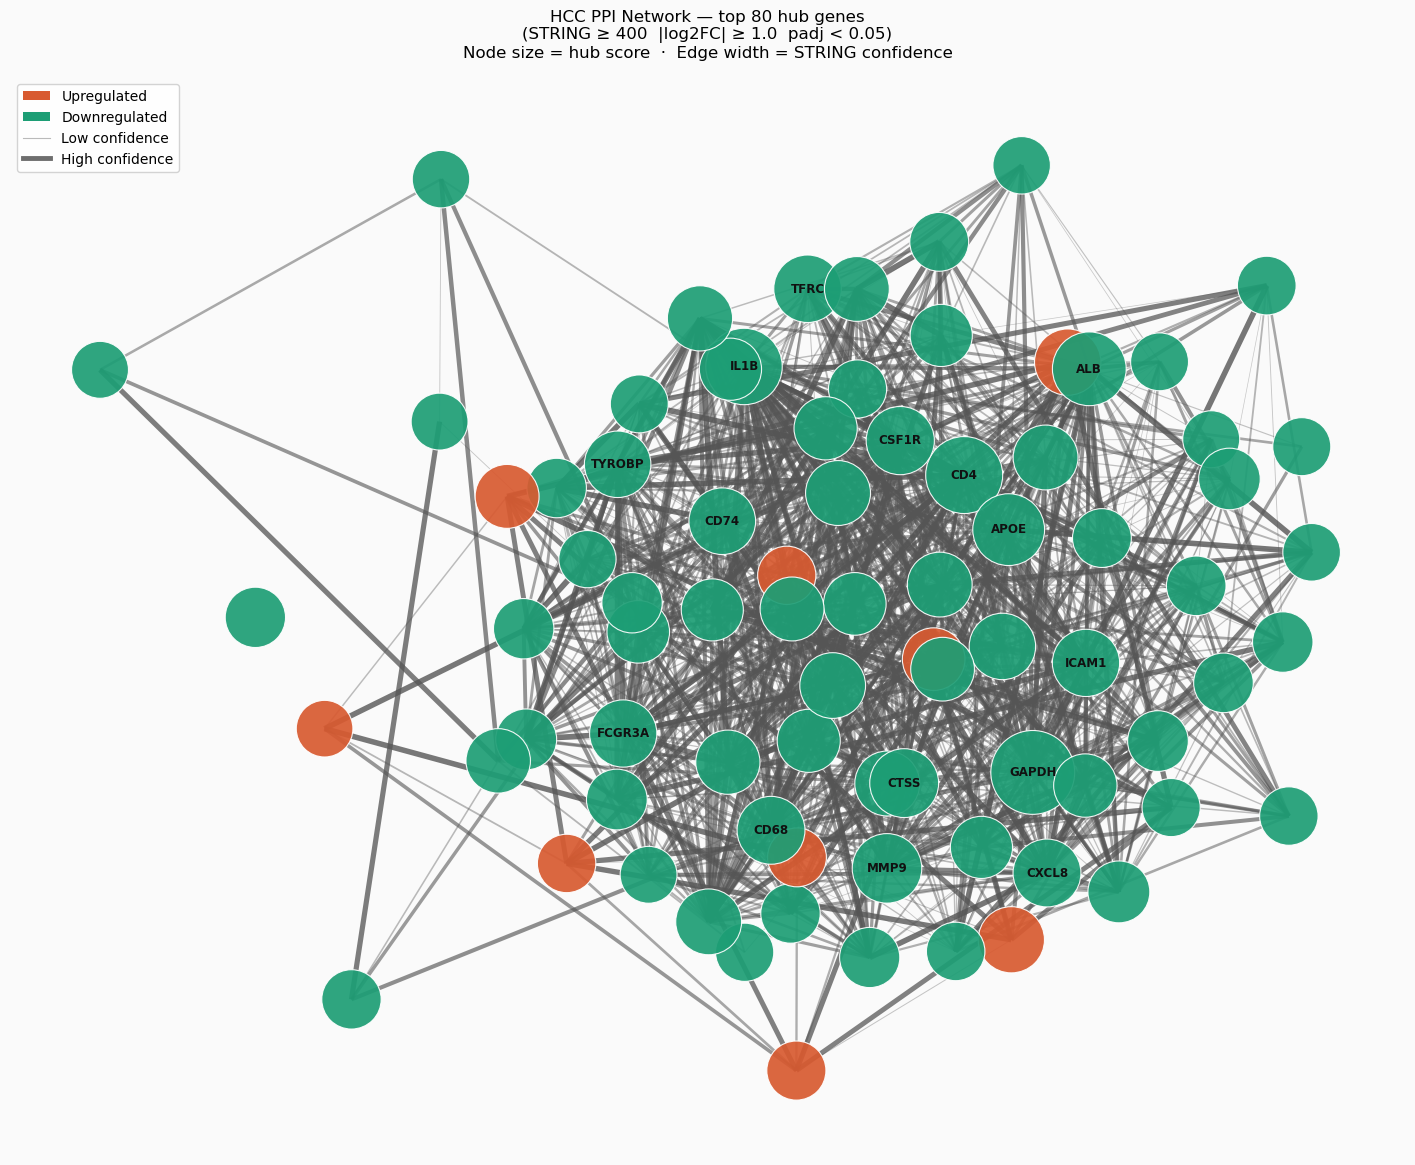

In [7]:
fig, _ = plot_ppi_network(G, hub_df,
                          top_nodes=TOP_VIZ_NODES,
                          string_score=STRING_SCORE,
                          log2fc_thresh=LOG2FC_THRESH,
                          padj_thresh=PADJ_THRESH)
fig.savefig(FIGURES_DIR / "ppi_network.png", dpi=200, bbox_inches="tight")
plt.show()

## 5 · Export

In [8]:
export_ppi(hub_df, G, edges_df, TABLES_DIR)

Saved: hub_genes.csv            (1162 genes)
Saved: ppi_edges_cytoscape.csv  (7551 edges)

Top 5 hub genes: ['GAPDH', 'CD4', 'IL1B', 'ALB', 'APOE']
